# Weather Data Visualization
### Apache Airflow Data Pipeline – Coursework
Connects to PostgreSQL and visualises the collected weather data for Colombo, Sri Lanka.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Pretty plot style
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

Matplotlib is building the font cache; this may take a moment.


In [2]:
# ── Connect to PostgreSQL ─────────────────────────────────────────────────────
# If running OUTSIDE Docker, use host='localhost'
conn = psycopg2.connect(
    host='localhost',
    port=5432,
    dbname='airflow',
    user='airflow',
    password='airflow'
)

query = """
    SELECT recorded_at, temperature_c, humidity_pct,
           wind_speed_kmh, precipitation_mm, weather_code
    FROM   weather_data
    WHERE  location = 'Colombo'
    ORDER  BY recorded_at;
"""

df = pd.read_sql(query, conn, parse_dates=['recorded_at'])
conn.close()

print(f'Loaded {len(df)} rows')
df.head()

Loaded 96 rows


,recorded_at,temperature_c,humidity_pct,wind_speed_kmh,precipitation_mm,weather_code
0,2026-04-24 00:00:00,28.4,82,14.4,0.9,80
1,2026-04-24 00:00:00,28.4,82,14.4,0.9,80
2,2026-04-24 00:00:00,28.4,82,14.4,0.9,80
3,2026-04-24 00:00:00,28.4,82,14.4,0.9,80
4,2026-04-24 01:00:00,28.4,82,12.9,0.4,80


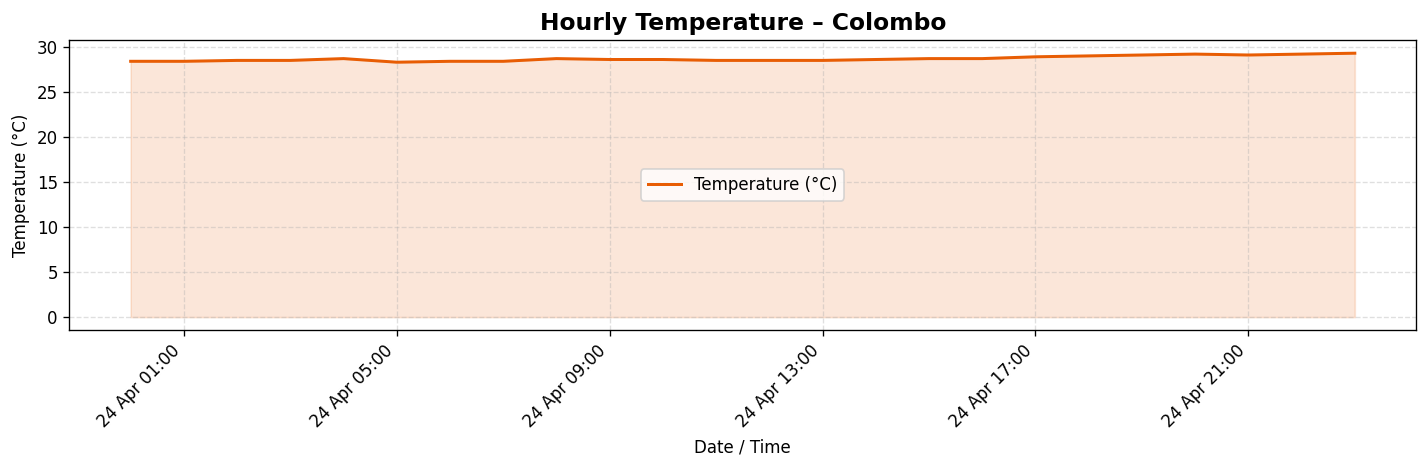

In [3]:
# ── 1. Temperature Time-Series ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['recorded_at'], df['temperature_c'], color='#E85D04', linewidth=1.8, label='Temperature (°C)')
ax.fill_between(df['recorded_at'], df['temperature_c'], alpha=0.15, color='#E85D04')
ax.set_title('Hourly Temperature – Colombo', fontsize=14, fontweight='bold')
ax.set_xlabel('Date / Time')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig('temperature_timeseries.png', bbox_inches='tight')
plt.show()

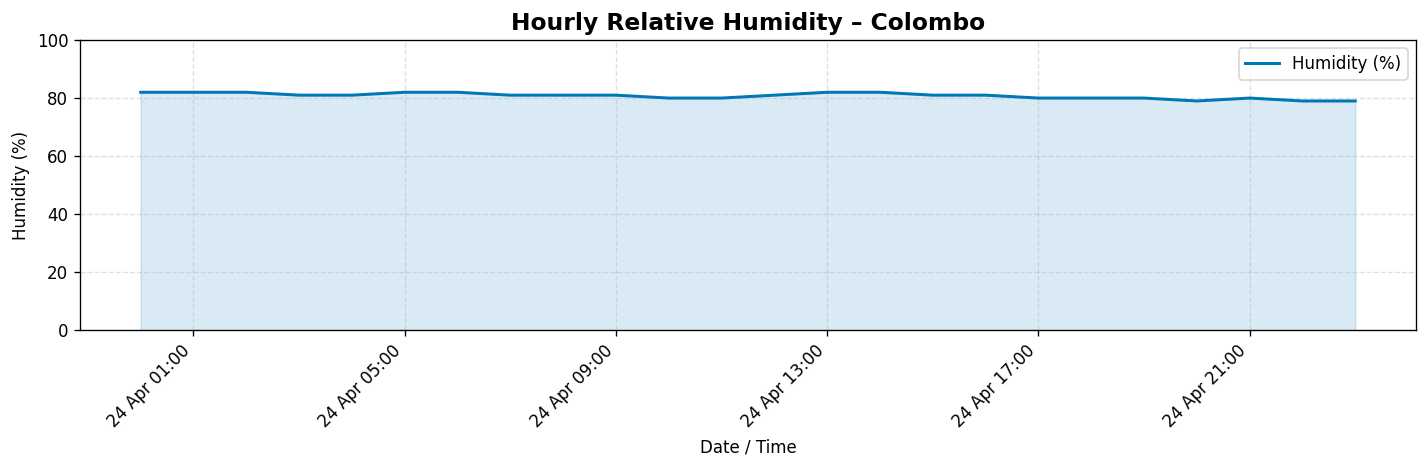

In [4]:
# ── 2. Humidity Time-Series ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['recorded_at'], df['humidity_pct'], color='#0077B6', linewidth=1.8, label='Humidity (%)')
ax.fill_between(df['recorded_at'], df['humidity_pct'], alpha=0.15, color='#0077B6')
ax.set_title('Hourly Relative Humidity – Colombo', fontsize=14, fontweight='bold')
ax.set_xlabel('Date / Time')
ax.set_ylabel('Humidity (%)')
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig('humidity_timeseries.png', bbox_inches='tight')
plt.show()

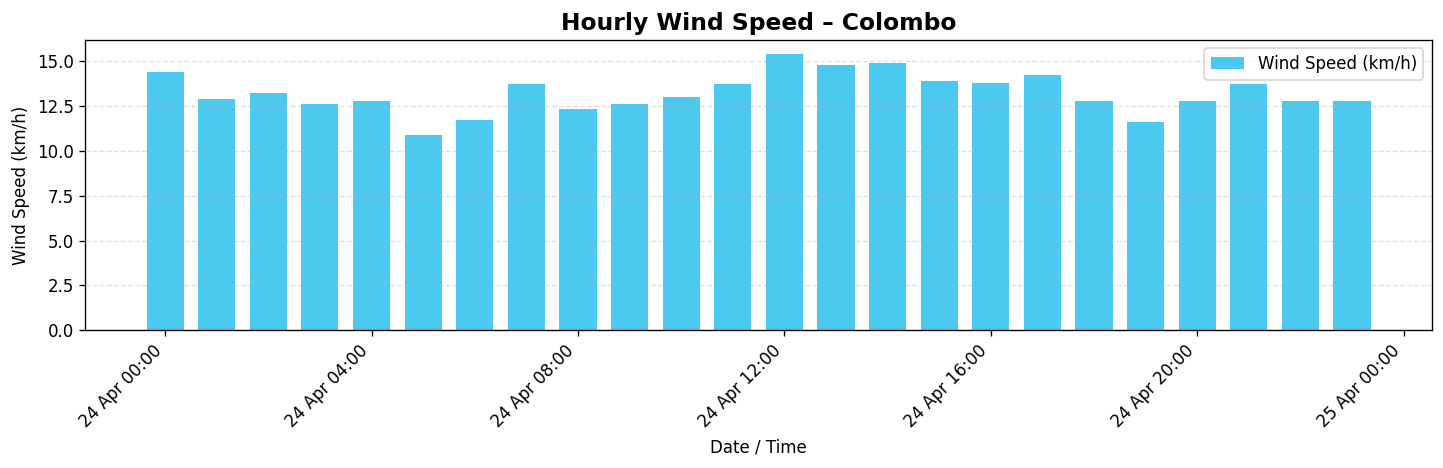

In [5]:
# ── 3. Wind Speed Time-Series ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df['recorded_at'], df['wind_speed_kmh'], color='#4CC9F0', width=0.03, label='Wind Speed (km/h)')
ax.set_title('Hourly Wind Speed – Colombo', fontsize=14, fontweight='bold')
ax.set_xlabel('Date / Time')
ax.set_ylabel('Wind Speed (km/h)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
ax.legend()
plt.tight_layout()
plt.savefig('windspeed_timeseries.png', bbox_inches='tight')
plt.show()

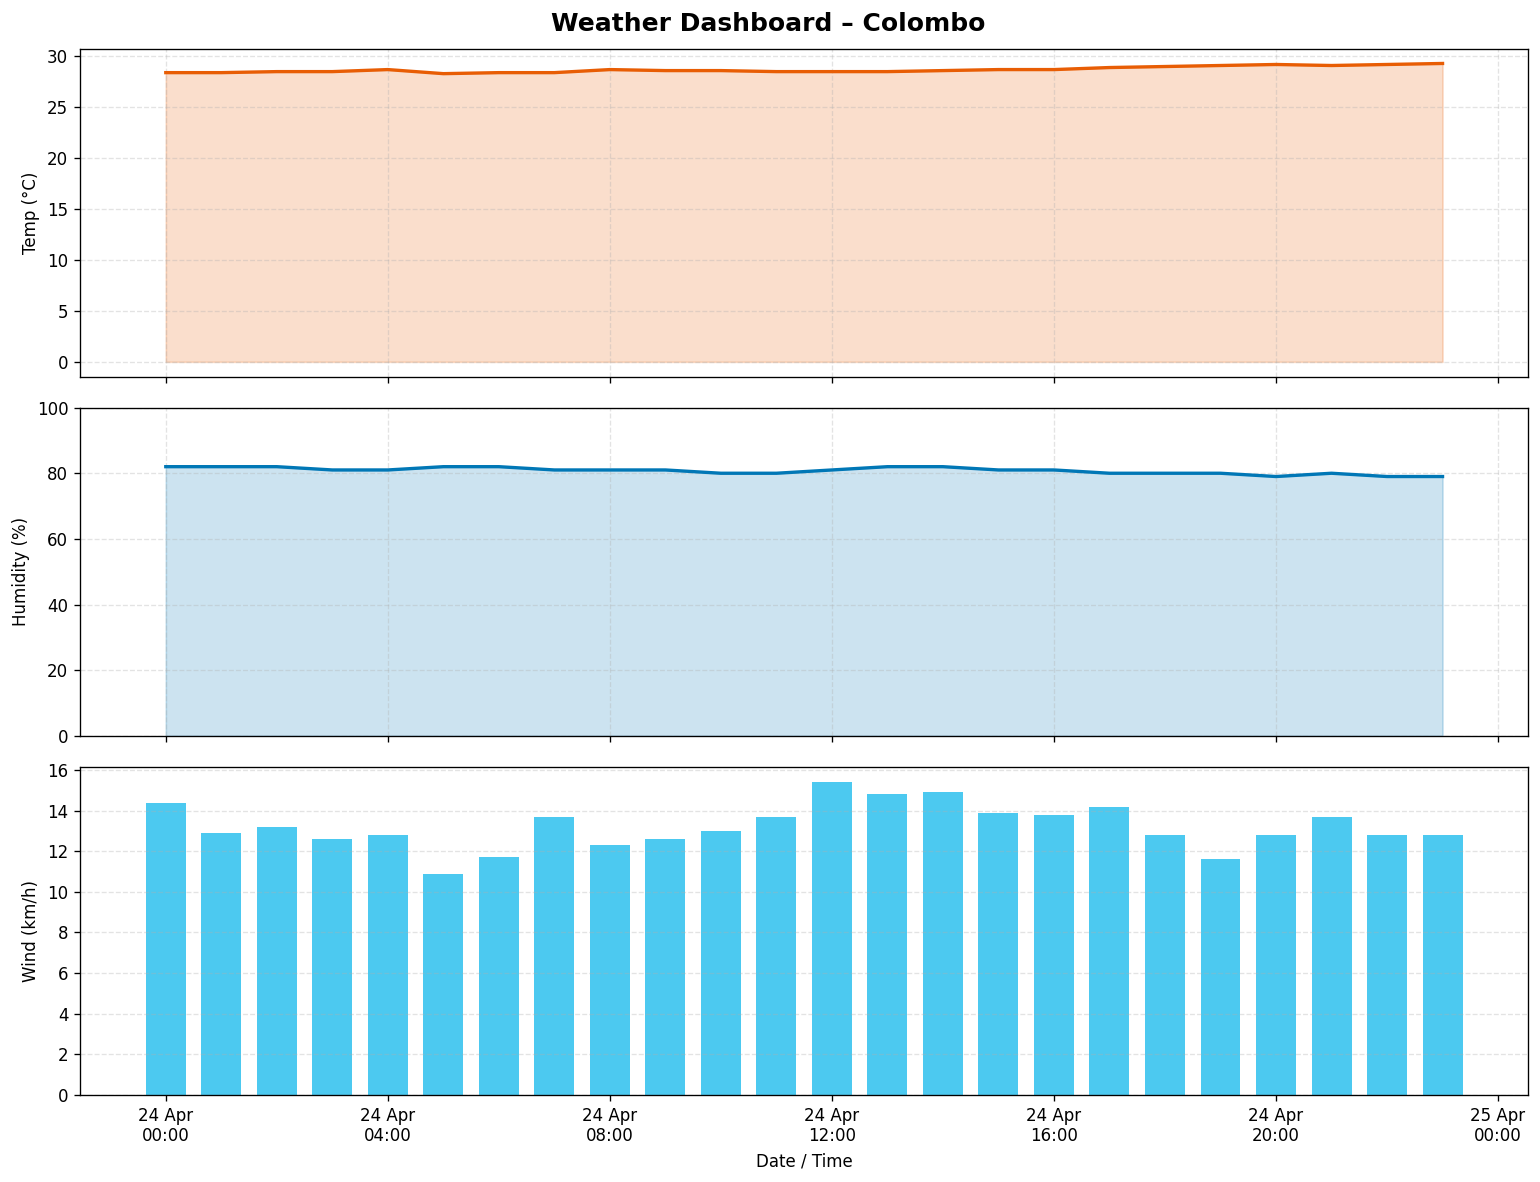

In [6]:
# ── 4. Multi-variable Comparison Dashboard ────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle('Weather Dashboard – Colombo', fontsize=15, fontweight='bold', y=0.98)

axes[0].plot(df['recorded_at'], df['temperature_c'], color='#E85D04', lw=2)
axes[0].set_ylabel('Temp (°C)')
axes[0].fill_between(df['recorded_at'], df['temperature_c'], alpha=0.2, color='#E85D04')
axes[0].grid(True, linestyle='--', alpha=0.35)

axes[1].plot(df['recorded_at'], df['humidity_pct'], color='#0077B6', lw=2)
axes[1].set_ylabel('Humidity (%)')
axes[1].set_ylim(0, 100)
axes[1].fill_between(df['recorded_at'], df['humidity_pct'], alpha=0.2, color='#0077B6')
axes[1].grid(True, linestyle='--', alpha=0.35)

axes[2].bar(df['recorded_at'], df['wind_speed_kmh'], color='#4CC9F0', width=0.03)
axes[2].set_ylabel('Wind (km/h)')
axes[2].set_xlabel('Date / Time')
axes[2].grid(True, linestyle='--', alpha=0.35, axis='y')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))
axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=4))

plt.tight_layout()
plt.savefig('weather_dashboard.png', bbox_inches='tight')
plt.show()

In [7]:
# ── 5. Summary Statistics ─────────────────────────────────────────────────────
print('=== Summary Statistics ===')
print(df[['temperature_c','humidity_pct','wind_speed_kmh','precipitation_mm']].describe().round(2))

=== Summary Statistics ===
       temperature_c  humidity_pct  wind_speed_kmh  precipitation_mm
count          96.00         96.00           96.00             96.00
mean           28.70         80.79           13.22              0.35
std             0.29          1.00            1.06              0.45
min            28.30         79.00           10.90              0.00
25%            28.50         80.00           12.75              0.00
50%            28.60         81.00           12.95              0.10
75%            28.92         82.00           13.82              0.60
max            29.30         82.00           15.40              1.60


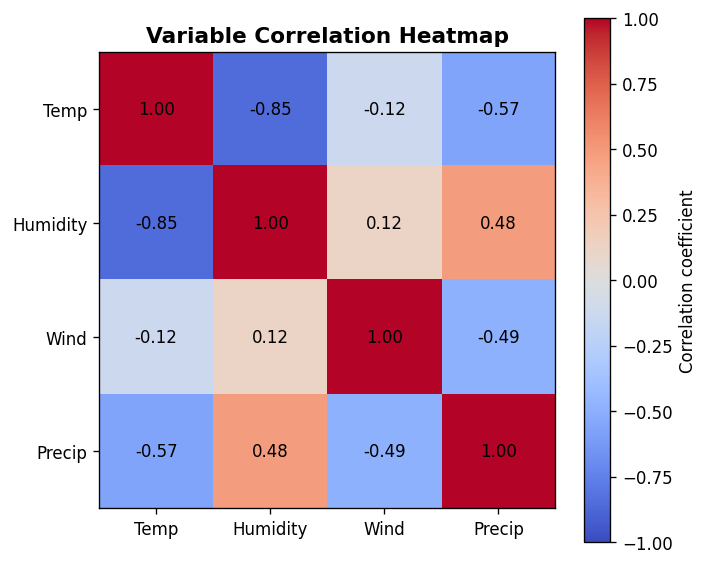

In [8]:
# ── 6. Correlation Heatmap ────────────────────────────────────────────────────
import numpy as np

cols  = ['temperature_c', 'humidity_pct', 'wind_speed_kmh', 'precipitation_mm']
corr  = df[cols].corr()
labels = ['Temp', 'Humidity', 'Wind', 'Precip']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlation coefficient')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_title('Variable Correlation Heatmap', fontsize=13, fontweight='bold')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                color='black', fontsize=10)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()